# LISA: Forcing Notebook

In [1]:
import os, sys, subprocess as sbp
import numpy as np
import matplotlib.pyplot as plt
os.environ["PIP_DISABLE_PIP_VERSION_CHECK"] = "1"
try:
    from lisa import LISA, ALSA
except:
    sbp.check_call([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/sparsetrace/LISA.git"])
    from lisa import LISA, ALSA

Trajectory shape: (18000, 3)
Metric eval starts: [6482 5456 4852 3694 3877 2596] ...
Using fixed start for 3D grid: a_start_plot=2650
Contexts: ['1L=75', '2L=150', '4L=300', '8L=600', '16L=1200', '20L=1500', '32L=2400']
[eval] LISA|1L: ell=75 steps=800 -> keys=['mse', 'spectral_kl', 'acf_mse', 'mmd2_rff']
[eval] ALSA|1L: ell=75 steps=800 -> keys=['mse', 'spectral_kl', 'acf_mse', 'mmd2_rff']
[eval] LISA|2L: ell=150 steps=800 -> keys=['mse', 'spectral_kl', 'acf_mse', 'mmd2_rff']
[eval] ALSA|2L: ell=150 steps=800 -> keys=['mse', 'spectral_kl', 'acf_mse', 'mmd2_rff']
[eval] LISA|4L: ell=300 steps=800 -> keys=['mse', 'spectral_kl', 'acf_mse', 'mmd2_rff']
[eval] ALSA|4L: ell=300 steps=800 -> keys=['mse', 'spectral_kl', 'acf_mse', 'mmd2_rff']
[eval] LISA|8L: ell=600 steps=800 -> keys=['mse', 'spectral_kl', 'acf_mse', 'mmd2_rff']
[eval] ALSA|8L: ell=600 steps=800 -> keys=['mse', 'spectral_kl', 'acf_mse', 'mmd2_rff']
[eval] LISA|16L: ell=1200 steps=800 -> keys=['mse', 'spectral_kl', 'acf_mse', 

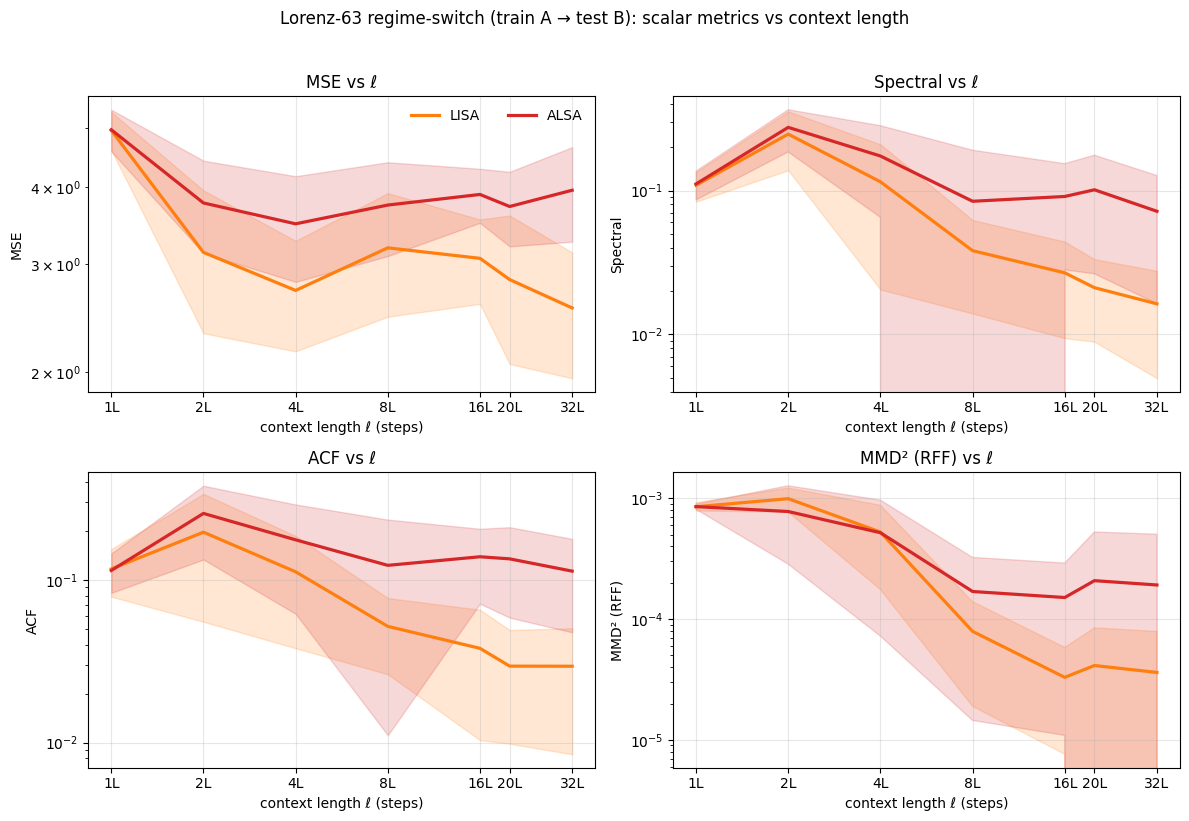

[grid] done ℓ=1L (75)
[grid] done ℓ=2L (150)
[grid] done ℓ=4L (300)
[grid] done ℓ=8L (600)
[grid] done ℓ=16L (1200)
[grid] done ℓ=20L (1500)
[grid] done ℓ=32L (2400)


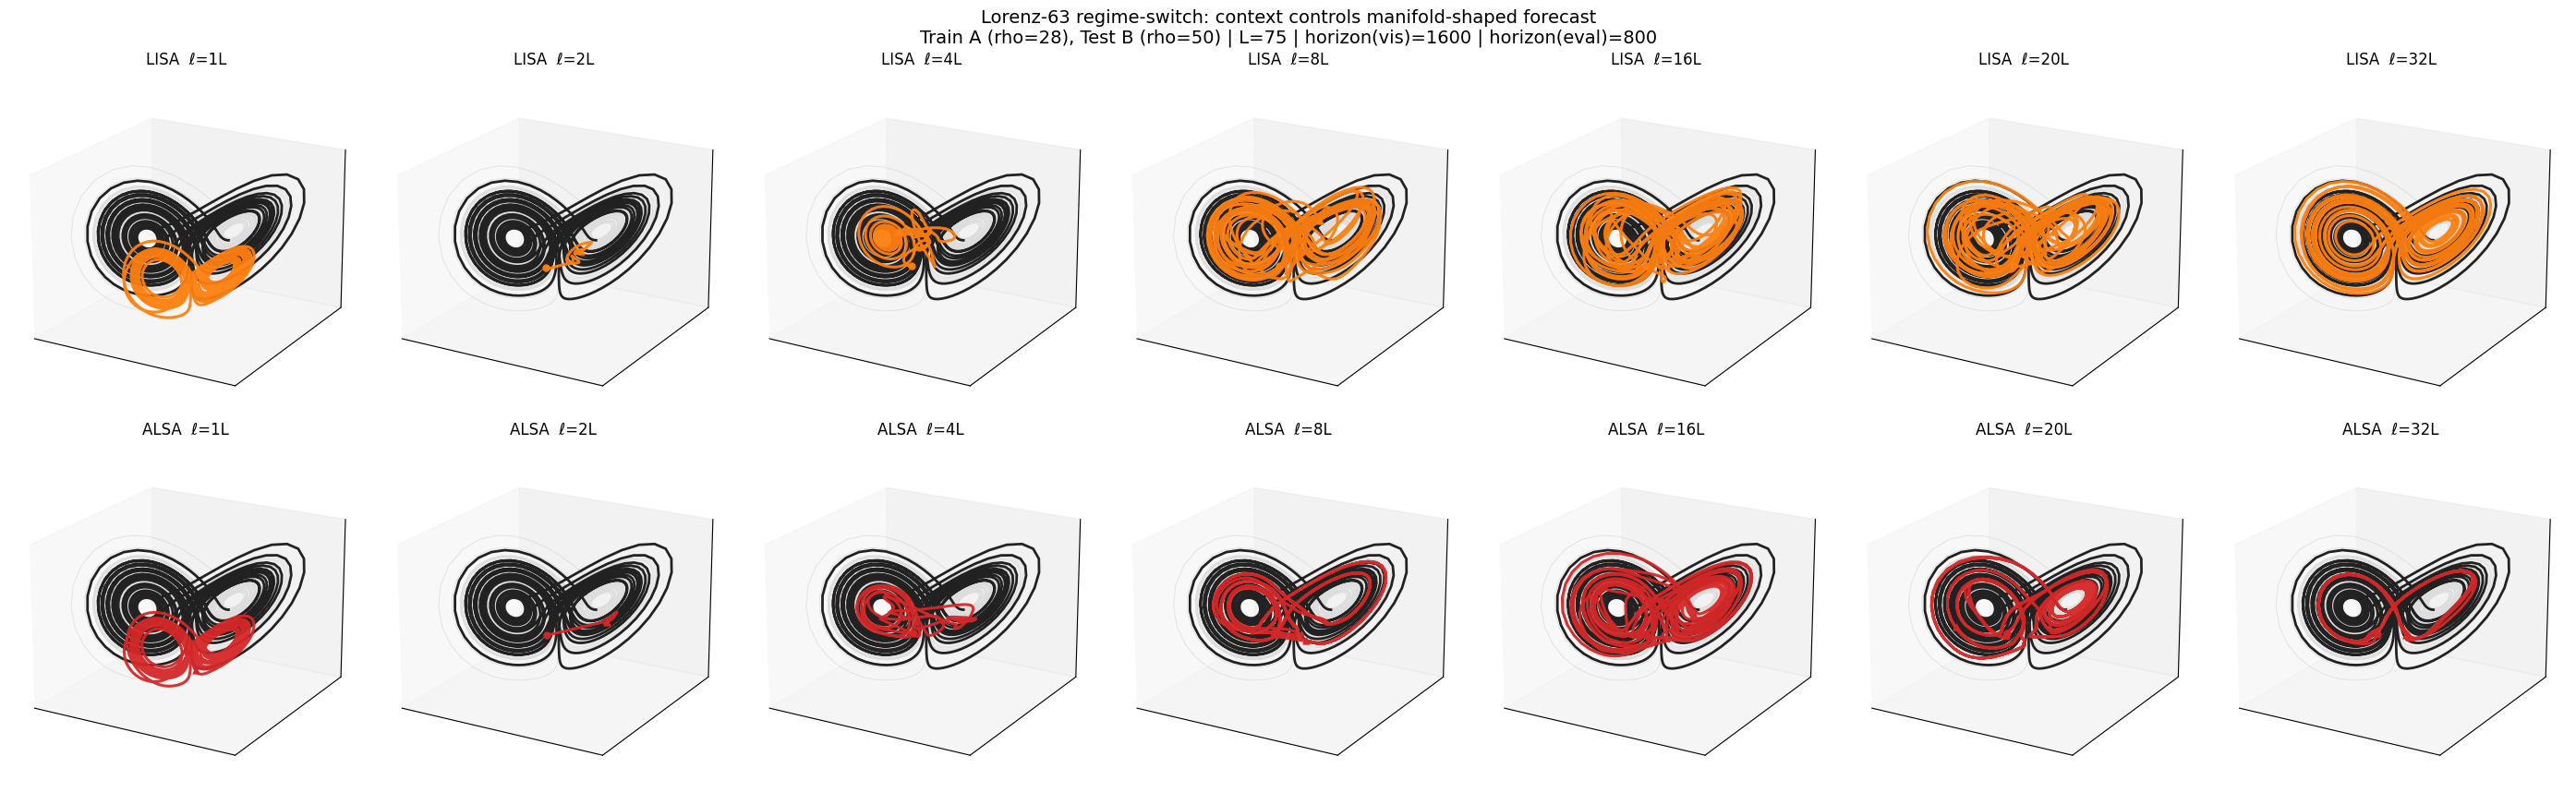


Saved figures in: figures/forcing_lorenz63


In [2]:
# forcing_test_lorenz63.py
# -*- coding: utf-8 -*-
"""
forcing_test_lorenz63.py

Nonstationarity test (regime-switch Lorenz-63):
- Train on regime A only
- Test on regime B
- Train ONE LISA + ONE ALSA
- Sweep context length ell = m*L over a grid (for a FIXED start) and show 3D panels:
    top row: LISA
    bottom row: ALSA
  Each panel shows regime-B attractor background (gray), truth (black), prediction (colored).

- Also: scalar metric vs ell plots (2x2 panel), averaged over multiple random starts in regime B.

Requirements:
  forcing.py (lorenz63_regime_switch, Lorenz63Params)
  LISA.py, ALSA.py
  metrics.py (compare_all_fast_with_curves using spectral_kl)
"""

from __future__   import annotations
from dataclasses  import dataclass
from lisa.forcing import lorenz63_regime_switch, Lorenz63Params
from lisa.metrics import compare_all_fast_with_curves

# ============================================================
# Config
# ============================================================

OUT_DIR = "figures/forcing_lorenz63"
os.makedirs(OUT_DIR, exist_ok=True)

# simulation
dt = 0.01
T_total = 20000
burn = 2000

T_train = 6000                      # regime A
T_test_cap = 8000                   # cap regime B length for speed

# forecast/model config
L = 75
rank = 32

steps_eval = 800                    # horizon used for *metrics* (keep modest)
steps_vis  = 1600                   # horizon used for *3D panels* (longer shows manifold)

multipliers = [1, 2, 4, 8, 16, 20, 32]   # grid columns
ell_list = [m * L for m in multipliers]
ell_max = max(ell_list)

# for metric panel (multi-start averaging)
N_STARTS = 12
SEED = 0

# regime switch
paramsA = Lorenz63Params(sigma=10.0, rho=28.0, beta=8.0/3.0)
paramsB = Lorenz63Params(sigma=16.0, rho=50.0, beta=3.0)  # strong shift


# ============================================================
# Helpers
# ============================================================

def standardize_train_only(F_train: np.ndarray, F_test: np.ndarray, eps: float = 1e-12):
    mu = F_train.mean(axis=0, keepdims=True)
    sd = F_train.std(axis=0, keepdims=True) + eps
    return (F_train - mu) / sd, (F_test - mu) / sd, mu, sd

def make_task(F_test_z: np.ndarray, a_start: int, ell_ctx: int, steps: int):
    prefix = F_test_z[a_start - ell_ctx : a_start, :]
    truth  = F_test_z[a_start : a_start + steps, :]
    return prefix, truth

def unstandardize(Z: np.ndarray, mu: np.ndarray, sd: np.ndarray) -> np.ndarray:
    return Z * sd + mu

def decimate(X: np.ndarray, max_points: int = 12000) -> np.ndarray:
    X = np.asarray(X)
    n = X.shape[0]
    if n <= max_points:
        return X
    stride = max(1, n // max_points)
    return X[::stride]

def set_equal_3d_limits(ax, all_xyz: np.ndarray, pad: float = 0.05):
    mins = all_xyz.min(axis=0)
    maxs = all_xyz.max(axis=0)
    ctr = 0.5 * (mins + maxs)
    span = float(np.max(maxs - mins)) * (1.0 + pad)
    ax.set_xlim(ctr[0] - span/2, ctr[0] + span/2)
    ax.set_ylim(ctr[1] - span/2, ctr[1] + span/2)
    ax.set_zlim(ctr[2] - span/2, ctr[2] + span/2)

# Simple consistent styles (you can import your COLORS/styles instead)
COLORS = dict(LISA="C1", ALSA="C3", Truth="k", BG="0.80")

def plot_context_grid_3d(
    bg_u: np.ndarray,
    truth_u: np.ndarray,
    preds_lisa_u: dict[int, np.ndarray],
    preds_alsa_u: dict[int, np.ndarray],
    *,
    title: str,
    elev: int = 20,
    azim: int = -60,
    max_bg_points: int = 14000,
    ):
    multipliers_sorted = sorted(preds_lisa_u.keys())
    M = len(multipliers_sorted)

    B = decimate(bg_u, max_bg_points)

    # global limits from everything drawn
    all_parts = [B, truth_u]
    for m in multipliers_sorted:
        all_parts.append(preds_lisa_u[m])
        all_parts.append(preds_alsa_u[m])
    all_xyz = np.concatenate(all_parts, axis=0)

    fig = plt.figure(figsize=(4.0 * M, 9.0))
    fig.suptitle(title, fontsize=14)

    def panel(ax, pred_u: np.ndarray, name: str, color: str):
        # background attractor
        ax.plot(B[:, 0], B[:, 1], B[:, 2], color=COLORS["BG"], lw=0.6, alpha=0.55)

        # truth (same for every panel)
        ax.plot(truth_u[:, 0], truth_u[:, 1], truth_u[:, 2], color=COLORS["Truth"], lw=2.0, alpha=0.85)

        # prediction
        P = np.asarray(pred_u)
        ax.plot(P[:, 0], P[:, 1], P[:, 2], color=color, lw=2.2, alpha=0.95)

        # markers: pred start/end
        ax.scatter(P[0, 0], P[0, 1], P[0, 2], s=25, color=color, alpha=0.95, marker="o")
        ax.scatter(P[-1, 0], P[-1, 1], P[-1, 2], s=25, color=color, alpha=0.95, marker="^")

        ax.set_title(name)
        ax.view_init(elev=elev, azim=azim)
        set_equal_3d_limits(ax, all_xyz)

        # clean look
        ax.grid(False)
        ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])

    # Row 1: LISA
    for j, m in enumerate(multipliers_sorted):
        ax = fig.add_subplot(2, M, 1 + j, projection="3d")
        panel(ax, preds_lisa_u[m], f"LISA  ℓ={m}L", color=COLORS["LISA"])

    # Row 2: ALSA
    for j, m in enumerate(multipliers_sorted):
        ax = fig.add_subplot(2, M, M + 1 + j, projection="3d")
        panel(ax, preds_alsa_u[m], f"ALSA  ℓ={m}L", color=COLORS["ALSA"])

    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "context_grid_3d.png"), dpi=200)
    plt.show()

def eval_multistart_metrics(
    model_name: str,
    predictor_fn,
    F_test_z: np.ndarray,
    *,
    starts: np.ndarray,
    ell_ctx: int,
    steps: int,
    dt: float,
    include_mmd_rff: bool = True,
    seed: int = 0,
    ):
    """
    For each start:
      prefix -> pred
      compare pred vs truth using compare_all_fast_with_curves (spectral_kl + acf + mse (+ optional mmd2_rff))
    Returns:
      mean_s: dict[str,float]
      std_s : dict[str,float]
      mean_c: dict[str,np.ndarray]  (averaged curves)
    """
    scalars_list = []
    curves_list = []

    for a_start in starts:
        prefix, truth = make_task(F_test_z, int(a_start), int(ell_ctx), int(steps))
        pred = predictor_fn(prefix)

        s, c = compare_all_fast_with_curves(
            truth, pred,
            dt=dt,
            include_mmd_rff=include_mmd_rff,
            # keep other defaults or set mmd_sample/mmd_rff_dim if you like
            seed=seed,
        )
        scalars_list.append(s)
        curves_list.append(c)

    # mean/std scalars
    keys = list(scalars_list[0].keys())
    mean_s = {k: float(np.mean([d[k] for d in scalars_list])) for k in keys}
    std_s  = {k: float(np.std( [d[k] for d in scalars_list])) for k in keys}

    # mean curves (only those present)
    curve_keys = list(curves_list[0].keys())
    mean_c = {}
    for ck in curve_keys:
        arr = np.stack([c[ck] for c in curves_list], axis=0)
        mean_c[ck] = np.mean(arr, axis=0)

    print(f"[eval] {model_name}: ell={ell_ctx} steps={steps} -> keys={keys}")
    return mean_s, std_s, mean_c

# -----------------------------
# 1) Simulate regime-switch Lorenz63
# -----------------------------
switch_step_full = burn + T_train
schedule = [(0, paramsA), (switch_step_full, paramsB)]

traj, info = lorenz63_regime_switch(
    T_total,
    dt=dt,
    schedule=schedule,
    burn_in=burn,
    return_params=True,
)

F = traj.astype(np.float64)  # (T_total-burn, 3)
print("Trajectory shape:", F.shape)

# Train/test split aligned with switch (after burn-in)
F_train = F[:T_train]               # regime A
F_test_full = F[T_train:]           # regime B
F_test = F_test_full[:T_test_cap]   # cap

# -----------------------------
# 2) Standardize with TRAIN stats only
# -----------------------------
F_train_z, F_test_z, mu, sd = standardize_train_only(F_train, F_test)

# -----------------------------
# 3) Choose starts (regime B) for metrics
# -----------------------------
rng = np.random.default_rng(SEED)
a_min = ell_max
a_max = F_test_z.shape[0] - steps_eval - 1
if a_max <= a_min:
    raise ValueError(
        f"Not enough test points for ell_max={ell_max} and steps_eval={steps_eval}. "
        f"Need test length > ell_max + steps_eval. Got {F_test_z.shape[0]}."
    )
starts = rng.integers(a_min, a_max, size=N_STARTS)
print("Metric eval starts:", starts[: min(6, len(starts))], "...")

# fixed start for 3D grid (must work for ell_max + steps_vis)
if F_test_z.shape[0] <= ell_max + steps_vis + 5:
    raise ValueError("Not enough test points for visualization grid (ell_max + steps_vis).")
a_start_plot = ell_max + 250
print(f"Using fixed start for 3D grid: a_start_plot={a_start_plot}")
print("Contexts:", [f"{m}L={m*L}" for m in multipliers])

# -----------------------------
# 4) Train ONE LISA + ONE ALSA on regime A only
# -----------------------------
gplm_kwargs_common = dict(
    m=2048,
    inducing="fps",
    sigma2=1e-3,
    jitter=1e-7,
)

lisa = LISA(
    F_train_z,
    L=L,
    rank=rank,
    seed=SEED,
    gplm_kwargs=gplm_kwargs_common,
)

alsa = ALSA(
    F_train_z,
    L=L,
    rank=rank,
    seed=SEED,
    gplm_kwargs=gplm_kwargs_common,
)

MODELS = {"LISA": lisa, "ALSA": alsa}

# -----------------------------
# 5) Metrics sweep (2x2 panel): mean ± std over starts in regime B
# -----------------------------
results_mean = {name: {} for name in MODELS.keys()}
results_std  = {name: {} for name in MODELS.keys()}

for m, ell_ctx in zip(multipliers, ell_list):
    tag = f"{m}L"

    # LISA
    mean_s, std_s, _ = eval_multistart_metrics(
        f"LISA|{tag}",
        lambda prefix: lisa(prefix, steps=steps_eval),
        F_test_z,
        starts=starts,
        ell_ctx=ell_ctx,
        steps=steps_eval,
        dt=dt,
        include_mmd_rff=True,
        seed=SEED,
    )
    results_mean["LISA"][tag] = mean_s
    results_std["LISA"][tag]  = std_s

    # ALSA
    mean_s, std_s, _ = eval_multistart_metrics(
        f"ALSA|{tag}",
        lambda prefix: alsa(prefix, steps=steps_eval),
        F_test_z,
        starts=starts,
        ell_ctx=ell_ctx,
        steps=steps_eval,
        dt=dt,
        include_mmd_rff=True,
        seed=SEED,
    )
    results_mean["ALSA"][tag] = mean_s
    results_std["ALSA"][tag]  = std_s

# pick 4 metrics for the panel
# (these keys match the "new code" you described)
metric_panel = [
    ("MSE", "mse"),
    ("Spectral", "spectral_kl"),
    ("ACF", "acf_mse"),
    ("MMD² (RFF)", "mmd2_rff"),
]

tags_in_order = [f"{m}L" for m in multipliers]
ell_vals = np.array([m * L for m in multipliers], dtype=float)

fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs = axs.reshape(-1)

for ax, (pretty, key) in zip(axs, metric_panel):
    for model_name in ["LISA", "ALSA"]:
        means = np.array([results_mean[model_name][tag][key] for tag in tags_in_order], dtype=float)
        stds  = np.array([results_std[model_name][tag][key]  for tag in tags_in_order], dtype=float)

        ax.plot(
            ell_vals, means,
            lw=2.3,
            color=COLORS[model_name],
            label=model_name,
        )
        ax.fill_between(
            ell_vals,
            means - stds,
            means + stds,
            color=COLORS[model_name],
            alpha=0.18,
        )

    ax.set_title(f"{pretty} vs ℓ")
    ax.set_xlabel("context length ℓ (steps)")
    ax.set_ylabel(pretty)
    ax.grid(True, alpha=0.3)
    ax.set_xscale("log", base=2)
    ax.set_xticks(ell_vals)
    ax.set_xticklabels([f"{m}L" for m in multipliers])

    # log-y is usually helpful; if the metric can hit 0, this may warn.
    # If that happens, switch to linear or symlog.
    ax.set_yscale("log")

axs[0].legend(frameon=False, ncol=2)
plt.suptitle(
    "Lorenz-63 regime-switch (train A → test B): scalar metrics vs context length",
    y=1.02
)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "metrics_panel_2x2.png"), dpi=200)
plt.show()

# -----------------------------
# 6) 3D grid (single start): background regime B + truth + predictions
# -----------------------------
bg_u = unstandardize(F_test_z, mu, sd)  # full regime-B trajectory (for background)

# truth for this start/horizon (use ell_max so truth is independent of ell)
prefix_z, truth_z = make_task(F_test_z, a_start_plot, ell_max, steps_vis)
truth_u = unstandardize(truth_z, mu, sd)

preds_lisa_u: dict[int, np.ndarray] = {}
preds_alsa_u: dict[int, np.ndarray] = {}

for m, ell_ctx in zip(multipliers, ell_list):
    prefix_z, _ = make_task(F_test_z, a_start_plot, ell_ctx, steps_vis)
    pred_lisa_z = lisa(prefix_z, steps=steps_vis)
    pred_alsa_z = alsa(prefix_z, steps=steps_vis)
    preds_lisa_u[m] = unstandardize(pred_lisa_z, mu, sd)
    preds_alsa_u[m] = unstandardize(pred_alsa_z, mu, sd)
    print(f"[grid] done ℓ={m}L ({ell_ctx})")

title = (
    "Lorenz-63 regime-switch: context controls manifold-shaped forecast\n"
    f"Train A (rho=28), Test B (rho=50) | L={L} | horizon(vis)={steps_vis} | horizon(eval)={steps_eval}"
)

plot_context_grid_3d(
    bg_u=bg_u,
    truth_u=truth_u,
    preds_lisa_u=preds_lisa_u,
    preds_alsa_u=preds_alsa_u,
    title=title,
    elev=20,
    azim=-60,
    max_bg_points=14000,
)

print(f"\nSaved figures in: {OUT_DIR}")

Trajectory shape: (18000, 3)
rho(t) min/max: 28.0 50.0

Using fixed ell=16L = 1200 and start=1450
Temperature sweep: [0.0625, 0.125, 0.25, 1, 2, 4, 8, 16]
Eval starts: [6302 5021 4266 2818 3046 1445] ...

Base lengthscales:
  LISA ell0: 16.3774
  ALSA ell0: 5.27798
Effective ell = ell0 * temp
done temp=0.0625
done temp=0.125
done temp=0.25
done temp=1
done temp=2
done temp=4
done temp=8
done temp=16


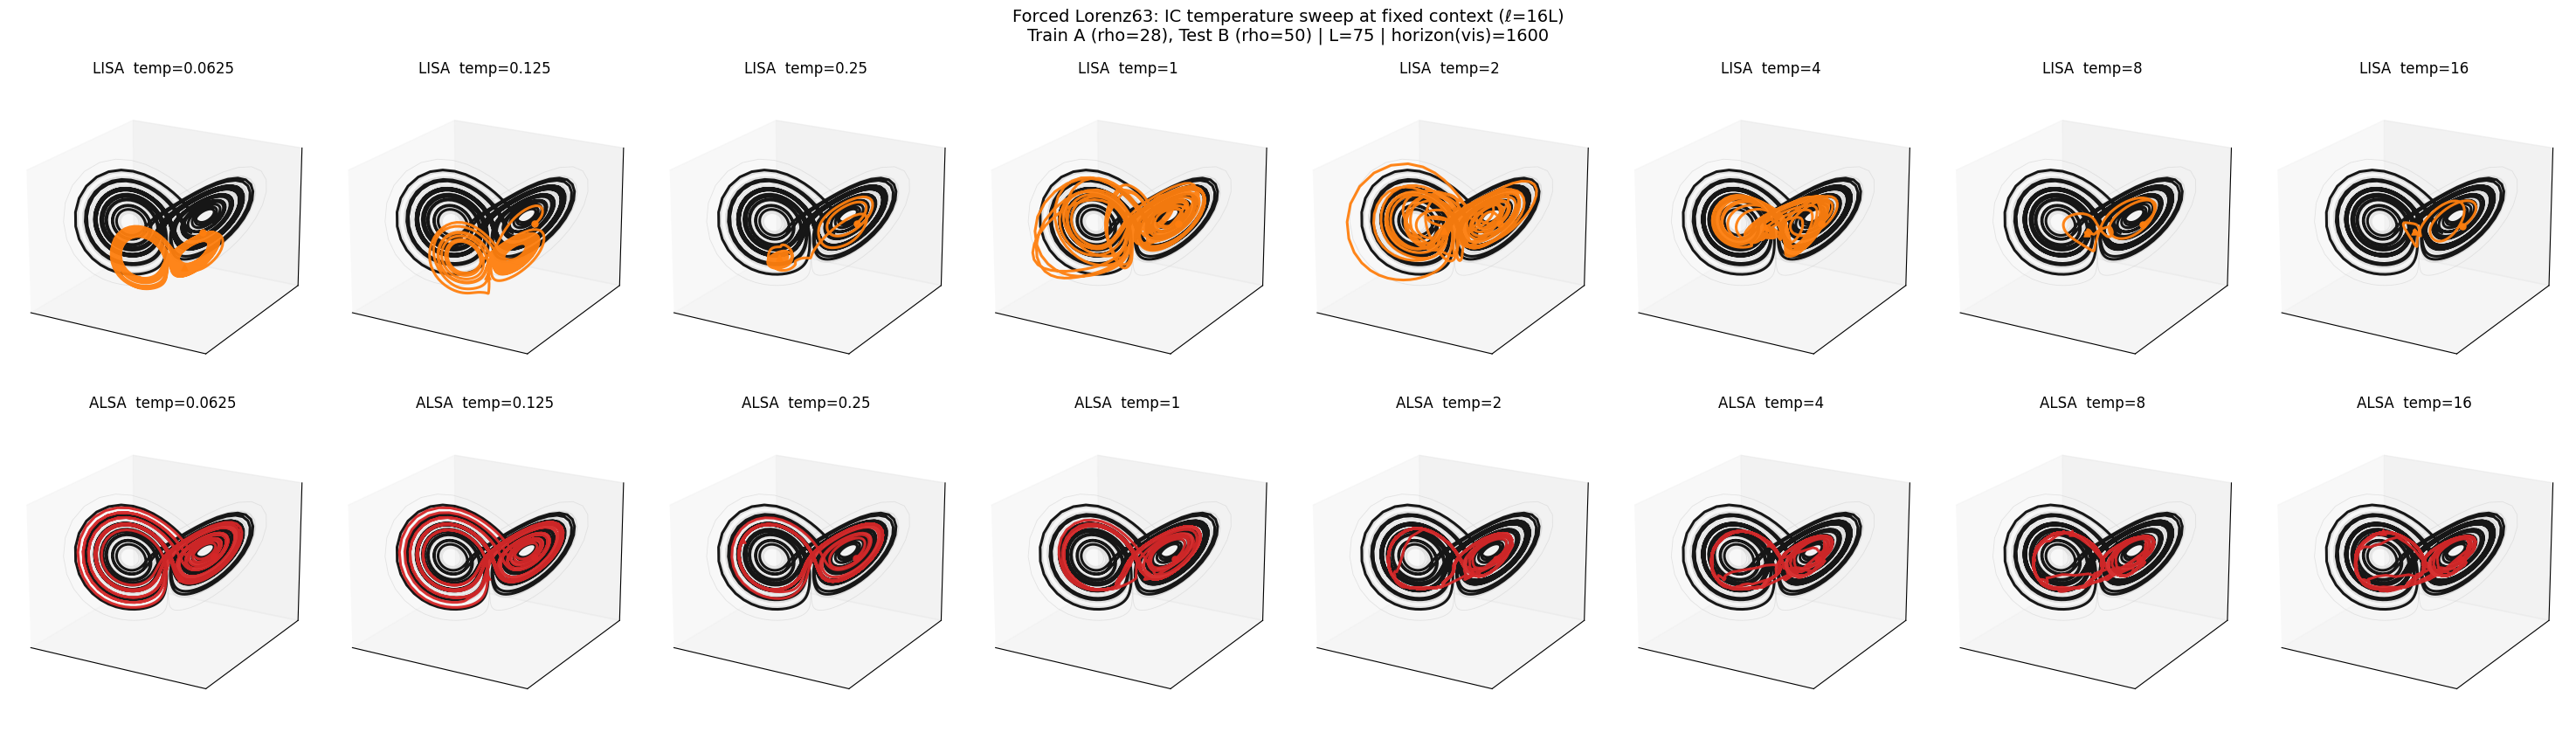

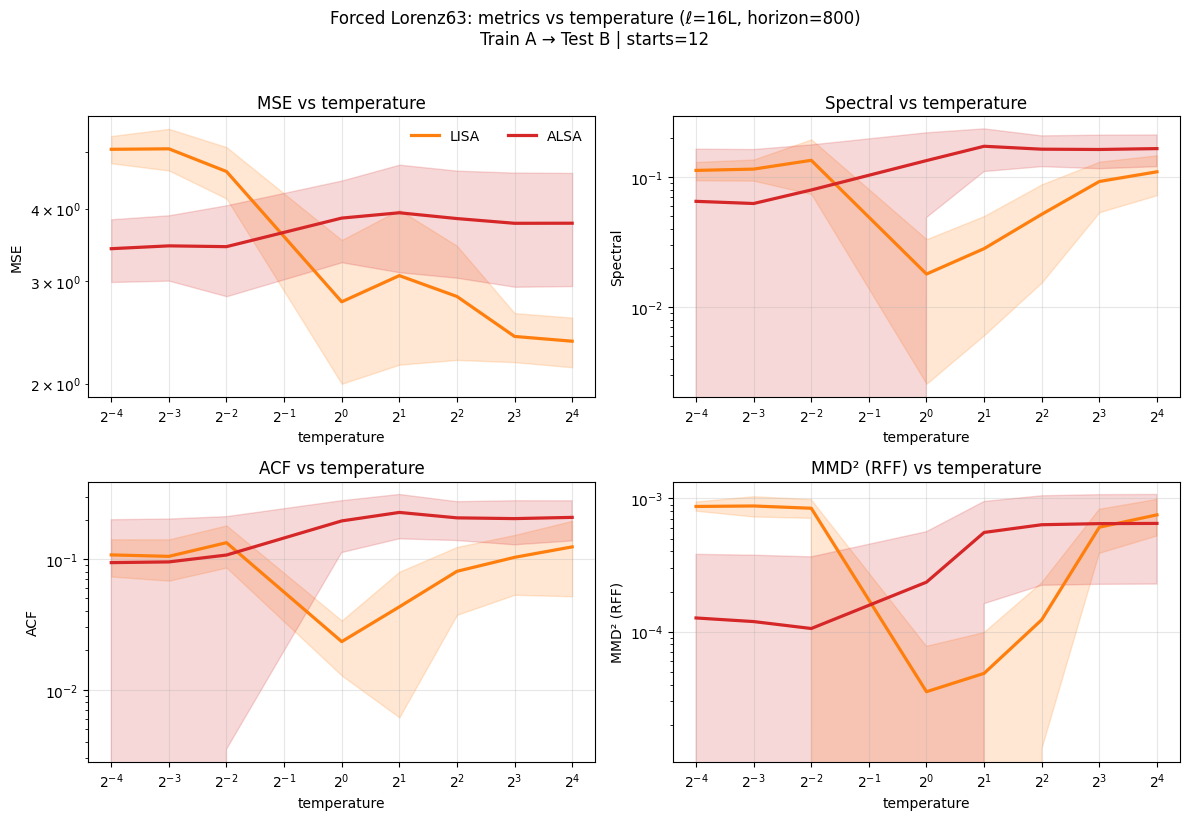


Saved figures in: figures/forcing_temperature


In [3]:
# test_forcing_temperature_new.py
# -*- coding: utf-8 -*-
"""
Forced Lorenz63 temperature sweep (new utilities style)

- Train on regime A only (rho=28)
- Test in regime B (rho=50)
- Fix context length ell = 16L
- Sweep temperature by scaling IC kernel lengthscales:
    LISA: gp_rbf_ell <- ell0_lisa * temp
    ALSA: attn_ell   <- ell0_alsa * temp

Outputs:
  A) 2 x M grid of 3D plots (LISA row, ALSA row)
     with regime-B background + truth + prediction
  B) (optional) 2x2 metric panel vs temp (mean ± std over starts)

Requirements:
  forcing.py (lorenz63_regime_switch, Lorenz63Params)
  LISA.py, ALSA.py
  metrics.py (compare_all_fast_with_curves using spectral_kl)
"""

from __future__ import annotations

import argparse
from typing import Dict, List, Optional
from numpy.lib.stride_tricks import sliding_window_view

from lisa.forcing import lorenz63_regime_switch, Lorenz63Params
from lisa.metrics import compare_all_fast_with_curves

# ============================================================
# Shared styles (same idea as your other scripts)
# ============================================================

def build_styles(COLORS: dict) -> dict[str, dict]:
    return {
        "Truth": dict(color="k", lw=2.2, ls="-", alpha=0.90),
        "LISA":  dict(color=COLORS.get("LISA", "C1"), lw=2.2, ls="-", alpha=0.95),
        "ALSA":  dict(color=COLORS.get("ALSA", "C3"), lw=2.2, ls="-", alpha=0.95),
        "BG":    dict(color="0.82", lw=0.6, alpha=0.55),
    }

COLORS = {"LISA": "C1", "ALSA": "C3"}
styles = build_styles(COLORS)


# ============================================================
# Utilities
# ============================================================

def standardize_train_only(F_train: np.ndarray, F_test: np.ndarray, eps: float = 1e-12):
    mu = F_train.mean(axis=0, keepdims=True)
    sd = F_train.std(axis=0, keepdims=True) + eps
    return (F_train - mu) / sd, (F_test - mu) / sd, mu, sd

def unstandardize(Z: np.ndarray, mu: np.ndarray, sd: np.ndarray) -> np.ndarray:
    return Z * sd + mu

def make_task(F_test_z: np.ndarray, a_start: int, ell_ctx: int, steps: int):
    prefix = F_test_z[a_start - ell_ctx : a_start, :]
    truth  = F_test_z[a_start : a_start + steps, :]
    return prefix, truth

def decimate(X: np.ndarray, max_points: int = 14000) -> np.ndarray:
    X = np.asarray(X)
    n = X.shape[0]
    if n <= max_points:
        return X
    stride = max(1, n // max_points)
    return X[::stride]

def set_equal_3d_limits(ax, all_xyz: np.ndarray, pad: float = 0.05):
    mins = all_xyz.min(axis=0)
    maxs = all_xyz.max(axis=0)
    ctr = 0.5 * (mins + maxs)
    span = float(np.max(maxs - mins)) * (1.0 + pad)
    ax.set_xlim(ctr[0] - span/2, ctr[0] + span/2)
    ax.set_ylim(ctr[1] - span/2, ctr[1] + span/2)
    ax.set_zlim(ctr[2] - span/2, ctr[2] + span/2)


# ============================================================
# 3D plotting: temperature grid (2 x M)
# ============================================================

def plot_temperature_grid_3d(
    bg_u: np.ndarray,
    truth_u: np.ndarray,
    preds_lisa_u: Dict[float, np.ndarray],
    preds_alsa_u: Dict[float, np.ndarray],
    *,
    title: str,
    elev: int = 20,
    azim: int = -60,
    max_bg_points: int = 14000,
    save_path: Optional[str] = None,
    show: bool = True,
    styles: dict[str, dict] | None = None,
):
    """
    2 x M grid:
      row 0: LISA predictions vs temp
      row 1: ALSA predictions vs temp
    Each panel: bg (regime B attractor) + truth + prediction.
    """
    if styles is None:
        styles = build_styles({"LISA": "C1", "ALSA": "C3"})

    temps = sorted(preds_lisa_u.keys())
    M = len(temps)

    B = decimate(bg_u, max_points=max_bg_points)

    # global axis limits from everything drawn
    all_parts = [B, truth_u]
    for t in temps:
        all_parts.append(preds_lisa_u[t])
        all_parts.append(preds_alsa_u[t])
    all_xyz = np.concatenate(all_parts, axis=0)

    fig = plt.figure(figsize=(3.7 * M, 8.8))
    fig.suptitle(title, fontsize=14)

    def panel(ax, pred_u: np.ndarray, panel_title: str, curve_style: dict):
        ax.plot(B[:, 0], B[:, 1], B[:, 2], **styles["BG"])
        ax.plot(truth_u[:, 0], truth_u[:, 1], truth_u[:, 2], **styles["Truth"])

        P = np.asarray(pred_u)
        ax.plot(P[:, 0], P[:, 1], P[:, 2], **curve_style)

        # markers: pred start/end
        ax.scatter(P[0, 0], P[0, 1], P[0, 2], s=26, color=curve_style.get("color", "C0"), marker="o", alpha=0.95)
        ax.scatter(P[-1, 0], P[-1, 1], P[-1, 2], s=26, color=curve_style.get("color", "C0"), marker="^", alpha=0.95)

        ax.set_title(panel_title)
        ax.view_init(elev=elev, azim=azim)
        set_equal_3d_limits(ax, all_xyz)

        ax.grid(False)
        ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])

    # LISA row
    for j, t in enumerate(temps):
        ax = fig.add_subplot(2, M, 1 + j, projection="3d")
        panel(ax, preds_lisa_u[t], f"LISA  temp={t:g}", styles.get("LISA", dict(color="C1", lw=2.2)))

    # ALSA row
    for j, t in enumerate(temps):
        ax = fig.add_subplot(2, M, M + 1 + j, projection="3d")
        panel(ax, preds_alsa_u[t], f"ALSA  temp={t:g}", styles.get("ALSA", dict(color="C3", lw=2.2)))

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print(f"[saved] {save_path}")

    if show:
        plt.show()
    else:
        plt.close(fig)


# ============================================================
# Temperature scaling helpers (same intent as your older code)
# ============================================================

def _sliding_windows(F_tD: np.ndarray, L: int) -> np.ndarray:
    F = np.asarray(F_tD, dtype=np.float64)
    if F.ndim == 1:
        F = F[:, None]
    W = sliding_window_view(F, window_shape=int(L), axis=0)

    # W can be (K,L,D) or (K,D,L)
    a, b = W.shape[1], W.shape[2]
    if (a, b) == (L, F.shape[1]):
        return np.ascontiguousarray(W)
    if (a, b) == (F.shape[1], L):
        return np.ascontiguousarray(np.transpose(W, (0, 2, 1)))
    raise ValueError(f"Unexpected window shape {W.shape} for L={L}, D={F.shape[1]}.")

def _pairwise_sq_dists(X: np.ndarray) -> np.ndarray:
    X = np.asarray(X, dtype=np.float64)
    x2 = np.sum(X * X, axis=1, keepdims=True)
    d2 = x2 + x2.T - 2.0 * (X @ X.T)
    np.maximum(d2, 0.0, out=d2)
    return d2

def _estimate_rbf_ell_from_d2(d2: np.ndarray, q: float = 0.5, eps: float = 1e-12) -> float:
    iu = np.triu_indices_from(d2, k=1)
    vals = d2[iu]
    if vals.size == 0:
        return 1.0
    qv = float(np.quantile(vals, q))
    ell = np.sqrt(max(qv, 0.0) / 2.0 + eps)
    return float(max(ell, 1e-6))

def estimate_lisa_context_ell0(lisa: LISA, prefix_z: np.ndarray, q: float = 0.5) -> float:
    """
    Estimate baseline ell0 using context latent geometry:
      ell^2 ≈ quantile(d^2)/2 on psi-distances among context windows.
    """
    L = int(lisa.L)
    ell_ctx = int(prefix_z.shape[0])
    K_ctx = ell_ctx - L
    if K_ctx <= 2:
        return 1.0

    W_all = _sliding_windows(prefix_z, L)         # (ell-L+1, L, D)
    W_ctx = np.ascontiguousarray(W_all[:K_ctx])   # (K_ctx, L, D)

    Psi = np.zeros((K_ctx, lisa.r), dtype=np.float64)
    for i in range(K_ctx):
        Psi[i] = lisa.base.encode_window(W_ctx[i])

    d2 = _pairwise_sq_dists(Psi)
    return _estimate_rbf_ell_from_d2(d2, q=q)


# ============================================================
# Optional: error panel vs temperature (2x2)
# ============================================================

def eval_metrics_over_starts(
    predictor_fn,
    F_test_z: np.ndarray,
    *,
    starts: np.ndarray,
    ell_ctx: int,
    steps: int,
    dt: float,
    include_mmd_rff: bool = True,
    seed: int = 0,
):
    scalars_list = []
    for a_start in starts:
        prefix, truth = make_task(F_test_z, int(a_start), int(ell_ctx), int(steps))
        pred = predictor_fn(prefix)

        s, _c = compare_all_fast_with_curves(
            truth, pred,
            dt=dt,
            include_mmd_rff=include_mmd_rff,
            seed=seed,
        )
        scalars_list.append(s)

    keys = list(scalars_list[0].keys())
    mean_s = {k: float(np.mean([d[k] for d in scalars_list])) for k in keys}
    std_s  = {k: float(np.std( [d[k] for d in scalars_list])) for k in keys}
    return mean_s, std_s

def plot_metric_panel_vs_temp(
    temps: List[float],
    results_mean: dict[str, dict[float, dict[str, float]]],
    results_std:  dict[str, dict[float, dict[str, float]]],
    *,
    title: str,
    save_path: Optional[str] = None,
):
    metric_panel = [
        ("MSE", "mse"),
        ("Spectral", "spectral_kl"),
        ("ACF", "acf_mse"),
        ("MMD² (RFF)", "mmd2_rff"),
    ]

    fig, axs = plt.subplots(2, 2, figsize=(12, 8))
    axs = axs.reshape(-1)

    x = np.array(temps, dtype=float)

    for ax, (pretty, key) in zip(axs, metric_panel):
        for model_name in ["LISA", "ALSA"]:
            y = np.array([results_mean[model_name][t][key] for t in temps], dtype=float)
            e = np.array([results_std[model_name][t][key]  for t in temps], dtype=float)

            ax.plot(x, y, lw=2.3, color=COLORS[model_name], label=model_name)
            ax.fill_between(x, y - e, y + e, color=COLORS[model_name], alpha=0.18)

        ax.set_title(f"{pretty} vs temperature")
        ax.set_xlabel("temperature")
        ax.set_ylabel(pretty)
        ax.grid(True, alpha=0.3)
        ax.set_xscale("log", base=2)
        ax.set_yscale("log")

    axs[0].legend(frameon=False, ncol=2)
    plt.suptitle(title, y=1.02)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print(f"[saved] {save_path}")

    plt.show()


# ============================================================
# Main sweep
# ============================================================

def run_temperature_sweep(
    *,
    temps: List[float],
    ell_mult: int,
    steps_vis: int,
    steps_eval: int,
    L: int,
    rank: int,
    seed: int,
    out_dir: str,
    save: bool,
    DO_ERROR_PANEL: bool,
    N_STARTS: int,
):
    os.makedirs(out_dir, exist_ok=True)

    # -----------------------------
    # 1) Simulate regime-switch Lorenz63
    # -----------------------------
    dt = 0.01
    T_total = 20000
    burn = 2000
    T_train = 6000
    switch_step_full = burn + T_train

    paramsA = Lorenz63Params(sigma=10.0, rho=28.0, beta=8.0 / 3.0)
    paramsB = Lorenz63Params(sigma=16.0, rho=50.0, beta=3.0)
    schedule = [(0, paramsA), (switch_step_full, paramsB)]

    traj, info = lorenz63_regime_switch(
        T_total,
        dt=dt,
        schedule=schedule,
        burn_in=burn,
        return_params=True,
    )

    F = traj.astype(np.float64)  # (T_total-burn, 3)
    rho_t = info.get("rho_t", None)
    print("Trajectory shape:", F.shape)
    if rho_t is not None:
        print("rho(t) min/max:", float(np.min(rho_t)), float(np.max(rho_t)))

    F_train = F[:T_train]       # regime A
    F_test_full = F[T_train:]   # regime B

    # cap test for speed
    T_test = 8000
    F_test = F_test_full[:T_test]

    # -----------------------------
    # 2) Standardize with TRAIN stats only
    # -----------------------------
    F_train_z, F_test_z, mu, sd = standardize_train_only(F_train, F_test)
    bg_u = unstandardize(F_test_z, mu, sd)

    # -----------------------------
    # 3) Fixed context ℓ = ell_mult * L
    # -----------------------------
    ell_ctx = int(ell_mult * L)
    if ell_ctx <= L:
        raise ValueError("Need ell_ctx > L for IC behavior.")
    if F_test_z.shape[0] <= ell_ctx + max(steps_vis, steps_eval) + 10:
        raise ValueError("Not enough test points for this ell_ctx and steps.")

    a_start_plot = ell_ctx + 250
    prefix_z_vis, truth_z_vis = make_task(F_test_z, a_start_plot, ell_ctx, steps_vis)
    truth_u_vis = unstandardize(truth_z_vis, mu, sd)

    print(f"\nUsing fixed ell={ell_mult}L = {ell_ctx} and start={a_start_plot}")
    print("Temperature sweep:", temps)

    # starts for error panel
    rng = np.random.default_rng(seed)
    a_min = ell_ctx
    a_max = F_test_z.shape[0] - steps_eval - 1
    if a_max <= a_min:
        raise ValueError("Not enough data for multistart eval.")
    starts = rng.integers(a_min, a_max, size=int(N_STARTS))
    print("Eval starts:", starts[: min(6, len(starts))], "...")

    # -----------------------------
    # 4) Train ONE LISA + ONE ALSA on regime A only
    # -----------------------------
    gplm = dict(m=2048, inducing="fps", sigma2=1e-3, jitter=1e-7)
    lisa = LISA(F_train_z, L=L, rank=rank, gplm_kwargs=gplm, seed=seed)
    alsa = ALSA(F_train_z, L=L, rank=rank, gplm_kwargs=gplm, seed=seed)

    # -----------------------------
    # 5) Base lengthscales (temp=1 references)
    # -----------------------------
    lisa_ell0 = estimate_lisa_context_ell0(lisa, prefix_z_vis, q=0.5)

    # ALSA: if it has attn_ell estimated internally use that; else fall back to lisa_ell0
    alsa_ell0 = float(getattr(alsa, "attn_ell", np.nan))
    if not np.isfinite(alsa_ell0) or alsa_ell0 <= 0:
        alsa_ell0 = float(lisa_ell0)

    print("\nBase lengthscales:")
    print(f"  LISA ell0: {lisa_ell0:.6g}")
    print(f"  ALSA ell0: {alsa_ell0:.6g}")
    print("Effective ell = ell0 * temp")

    # store originals
    lisa_gp_ell_orig = getattr(lisa, "gp_rbf_ell", None)
    alsa_attn_ell_orig = getattr(alsa, "attn_ell", None)

    preds_lisa_u: Dict[float, np.ndarray] = {}
    preds_alsa_u: Dict[float, np.ndarray] = {}

    # optional metrics
    results_mean: dict[str, dict[float, dict[str, float]]] = {"LISA": {}, "ALSA": {}}
    results_std:  dict[str, dict[float, dict[str, float]]] = {"LISA": {}, "ALSA": {}}

    # -----------------------------
    # 6) Sweep temps
    # -----------------------------
    for t in temps:
        t = float(t)

        # set temperature-scaled lengthscales
        lisa.gp_rbf_ell = lisa_ell0 * t
        alsa.attn_ell   = alsa_ell0 * t

        # 3D predictions (vis horizon)
        pred_lisa_z = lisa(prefix_z_vis, steps=steps_vis)
        pred_alsa_z = alsa(prefix_z_vis, steps=steps_vis)

        preds_lisa_u[t] = unstandardize(pred_lisa_z, mu, sd)
        preds_alsa_u[t] = unstandardize(pred_alsa_z, mu, sd)

        # metric panel (eval horizon) averaged over starts
        if DO_ERROR_PANEL:
            mean_s, std_s = eval_metrics_over_starts(
                lambda prefix: lisa(prefix, steps=steps_eval),
                F_test_z,
                starts=starts,
                ell_ctx=ell_ctx,
                steps=steps_eval,
                dt=dt,
                include_mmd_rff=True,
                seed=seed,
            )
            results_mean["LISA"][t] = mean_s
            results_std["LISA"][t]  = std_s

            mean_s, std_s = eval_metrics_over_starts(
                lambda prefix: alsa(prefix, steps=steps_eval),
                F_test_z,
                starts=starts,
                ell_ctx=ell_ctx,
                steps=steps_eval,
                dt=dt,
                include_mmd_rff=True,
                seed=seed,
            )
            results_mean["ALSA"][t] = mean_s
            results_std["ALSA"][t]  = std_s

        print(f"done temp={t:g}")

    # restore
    lisa.gp_rbf_ell = lisa_gp_ell_orig
    alsa.attn_ell = alsa_attn_ell_orig

    # -----------------------------
    # 7) Plots
    # -----------------------------
    title_grid = (
        f"Forced Lorenz63: IC temperature sweep at fixed context (ℓ={ell_mult}L)\n"
        f"Train A (rho=28), Test B (rho=50) | L={L} | horizon(vis)={steps_vis}"
    )

    grid_path = os.path.join(out_dir, "forcing_temperature_grid_3d.png") if save else None
    plot_temperature_grid_3d(
        bg_u=bg_u,
        truth_u=truth_u_vis,
        preds_lisa_u=preds_lisa_u,
        preds_alsa_u=preds_alsa_u,
        title=title_grid,
        elev=20,
        azim=-60,
        max_bg_points=14000,
        save_path=grid_path,
        show=True,
        styles=styles,
    )

    if DO_ERROR_PANEL:
        title_panel = (
            f"Forced Lorenz63: metrics vs temperature (ℓ={ell_mult}L, horizon={steps_eval})\n"
            f"Train A → Test B | starts={N_STARTS}"
        )
        panel_path = os.path.join(out_dir, "forcing_temperature_metrics_panel.png") if save else None
        plot_metric_panel_vs_temp(
            temps=temps,
            results_mean=results_mean,
            results_std=results_std,
            title=title_panel,
            save_path=panel_path,
        )

    print(f"\nSaved figures in: {out_dir}")


# ============================================================
# CLI
# ============================================================

def parse_args():
    p = argparse.ArgumentParser()
    p.add_argument("--temps", type=float, nargs="+", default=[1/16, 1/8, 1/4, 1, 2, 4, 8, 16])
    p.add_argument("--ell_mult", type=int, default=16)
    p.add_argument("--steps_vis", type=int, default=1600)
    p.add_argument("--steps_eval", type=int, default=800)
    p.add_argument("--L", type=int, default=75)
    p.add_argument("--rank", type=int, default=32)
    p.add_argument("--seed", type=int, default=0)
    p.add_argument("--n_starts", type=int, default=12)
    p.add_argument("--out_dir", type=str, default="figures/forcing_temperature")
    p.add_argument("--save", action="store_true")
    p.add_argument("--no_error_panel", action="store_true")
    args, _unknown = p.parse_known_args()
    return args


args = parse_args()
run_temperature_sweep(
    temps=list(args.temps),
    ell_mult=int(args.ell_mult),
    steps_vis=int(args.steps_vis),
    steps_eval=int(args.steps_eval),
    L=int(args.L),
    rank=int(args.rank),
    seed=int(args.seed),
    out_dir=str(args.out_dir),
    save=bool(args.save),
    DO_ERROR_PANEL=not bool(args.no_error_panel),
    N_STARTS=int(args.n_starts),
)
